In [1]:
import numpy as numpy
import pandas as pd
import matplotlib.pyplot as plt


In [13]:
df = pd.read_parquet('data/DKHousingPrices.parquet', engine='pyarrow')
df['date'] = pd.to_datetime(df['date'])
print("Original shape:", df.shape)

mask = df['zip_code'].between(1000, 2720)
print("Rows matching København:", mask.sum())

df = df[mask].copy()

# Map postal codes to neighborhoods using ranges
def map_zip_to_district(zip_code):
    # Indre By (City Center)
    if 1000 <= zip_code <= 1499:
        return 'Indre By'
    
    # Østerbro
    elif zip_code in [2100, 2150]:
        return 'Østerbro'
    
    # Nørrebro
    elif 2200 <= zip_code <= 2204:
        return 'Nørrebro'
    
    # Vesterbro/Kongens Enghave (includes Sydhavn 2450)
    elif 1500 <= zip_code <= 1799 or zip_code == 2450:
        return 'Vesterbro'
    
    # Valby
    elif zip_code == 2500:
        return 'Valby'
    
    # Vanløse
    elif zip_code == 2720:
        return 'Vanløse'
    
    # Brønshøj-Husum
    elif zip_code == 2700:
        return 'Brønshøj-Husum'
    
    # Bispebjerg (includes Nordvest)
    elif 2400 <= zip_code <= 2404:
        return 'Bispebjerg'
    
    # Amager Øst & Vest
    elif zip_code == 2300:
        return 'Amager'
    
    # Frederiksberg (Separate municipality, but often grouped)
    elif zip_code == 2000 or 1800 <= zip_code <= 1999:
        return 'Frederiksberg'
        
    return None
df['neighborhood'] = df['zip_code'].apply(map_zip_to_district)

# Show unmatched postal codes
unmatched = df[df['neighborhood'].isna()]['zip_code'].unique()
if len(unmatched) > 0:
    print(f"Unmatched postal codes: {sorted(unmatched)}")

df.drop(columns=['quarter', 'house_id', 'city', 'area', 'region'], inplace=True, errors='ignore')
df.reset_index(drop=True, inplace=True)
df.head()

Original shape: (1507908, 19)
Rows matching København: 150382
Unmatched postal codes: [np.int16(2600), np.int16(2605), np.int16(2610), np.int16(2620), np.int16(2625), np.int16(2630), np.int16(2635), np.int16(2640), np.int16(2650), np.int16(2660), np.int16(2665), np.int16(2670), np.int16(2680), np.int16(2690)]


,date,house_type,sales_type,year_build,purchase_price,%_change_between_offer_and_purchase,no_rooms,sqm,sqm_price,address,zip_code,nom_interest_rate%,dk_ann_infl_rate%,yield_on_mortgage_credit_bonds%,neighborhood
0,2024-10-24,Villa,regular_sale,1997,6500000,-3.0,5,142.0,45774.648438,Spættevej 16,2680,3.1,NaN,NaN,None
1,2024-10-24,Apartment,regular_sale,2006,4115000,0.0,3,77.0,53441.558594,"Teglholmsgade 8B, 3. th",2450,3.1,NaN,NaN,Vesterbro
2,2024-10-24,Apartment,regular_sale,1885,3400000,0.0,2,46.0,73913.046875,"Jakob Dannefærds Vej 10B, 4. th",1973,3.1,NaN,NaN,Frederiksberg
3,2024-10-24,Villa,family_sale,1929,4750000,0.0,4,118.0,40254.238281,Herfølgevej 19,2700,3.1,NaN,NaN,Brønshøj-Husum
4,2024-10-23,Villa,regular_sale,1949,4550000,-4.0,4,112.0,40625.000000,Vestre Plantagevej 3,2680,3.1,NaN,NaN,None


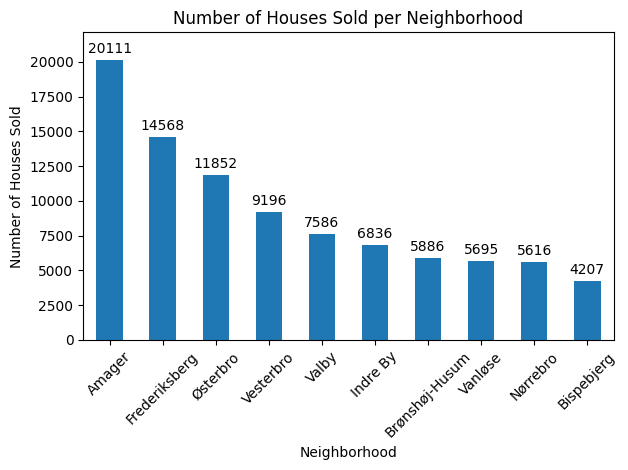

In [15]:
ax = df['neighborhood'].value_counts().plot(kind='bar')
ax.bar_label(ax.containers[0], padding=3)
plt.title('Number of Houses Sold per Neighborhood')
plt.xlabel('Neighborhood')
plt.ylabel('Number of Houses Sold')
plt.ylim(0, df['neighborhood'].value_counts().max() * 1.1)
plt.xticks(rotation=45)
plt.tight_layout()

In [17]:
df.groupby('neighborhood')['purchase_price'].agg(['mean', 'median', 'std'])

,mean,median,std
neighborhood,,,
Amager,3.274996e+06,2895000.0,2.067358e+06
Bispebjerg,2.536727e+06,2150000.0,1.626489e+06
Brønshøj-Husum,2.814610e+06,2400000.0,1.808526e+06
Frederiksberg,3.793048e+06,3300000.0,2.483333e+06
Indre By,4.280457e+06,3700000.0,2.803818e+06
Nørrebro,2.743367e+06,2469000.0,1.647398e+06
Valby,3.051307e+06,2660000.0,2.030047e+06
Vanløse,2.810252e+06,2330000.0,1.887941e+06
Vesterbro,3.956808e+06,3642085.5,2.271774e+06


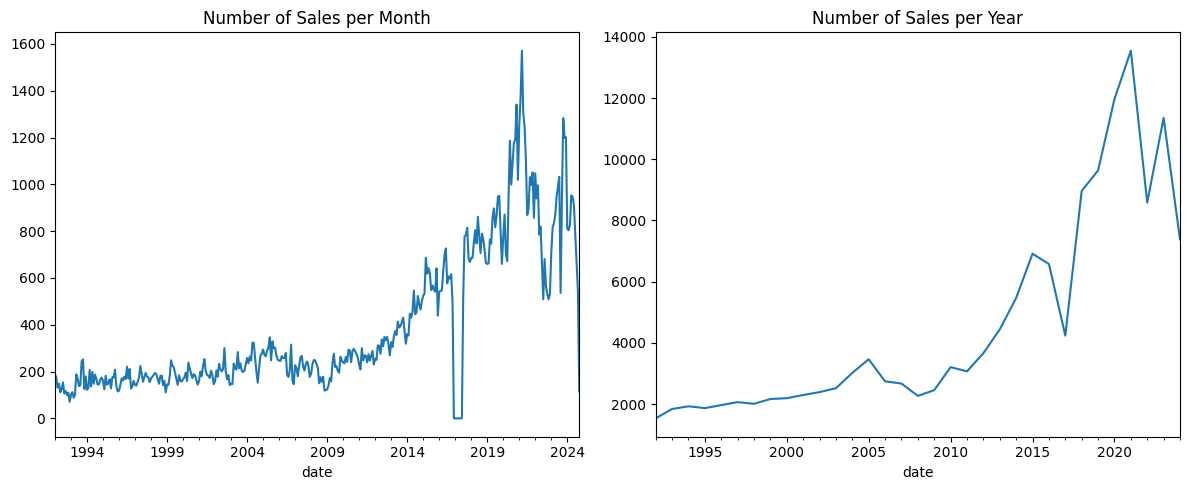

In [18]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

ts = df.set_index('date').resample('D').size()  # Daily counts of sales

# By month
ts_month = ts.resample('MS').sum()  # MS = month start
ts_month.plot(ax=axes[0])
axes[0].set_title('Number of Sales per Month')

# By year
ts_year = ts.resample('YS').sum()   # YS = year start
ts_year.plot(ax=axes[1])
axes[1].set_title('Number of Sales per Year')

plt.tight_layout()
plt.show()

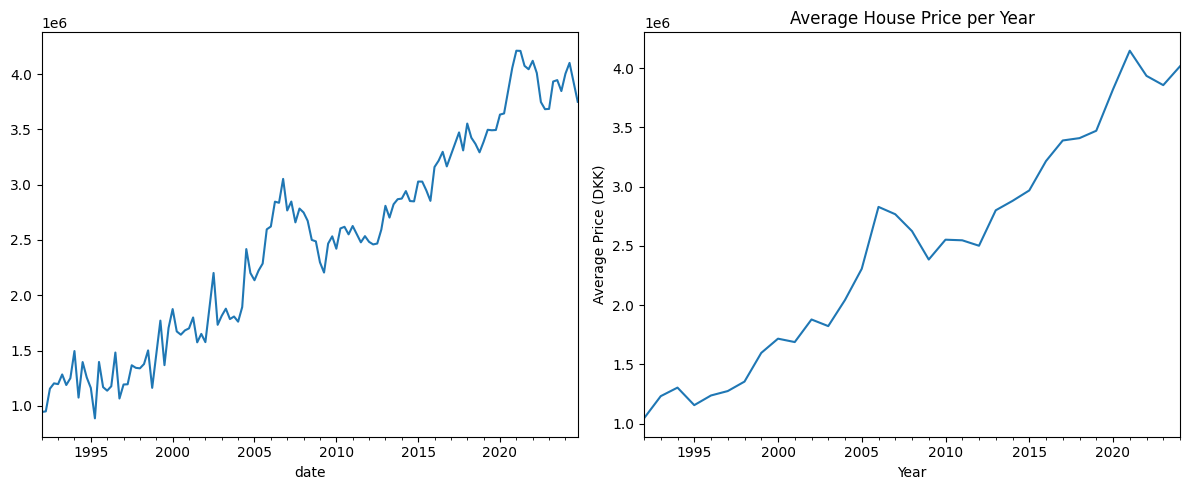

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
# Average house price per quarter
avg_price_quarter = df.groupby(df['date'].dt.to_period('Q'))['purchase_price'].mean()
avg_price_quarter.plot(ax=axes[0])
plt.title('Average House Price per Quarter')
plt.xlabel('Quarter')
plt.ylabel('Average Price (DKK)')
plt.tight_layout()



avg_price_year = df.groupby(df['date'].dt.to_period('Y'))['purchase_price'].mean()
avg_price_year.plot(ax=axes[1])
plt.title('Average House Price per Year')
plt.xlabel('Year')
plt.ylabel('Average Price (DKK)')
plt.tight_layout()
plt.show()

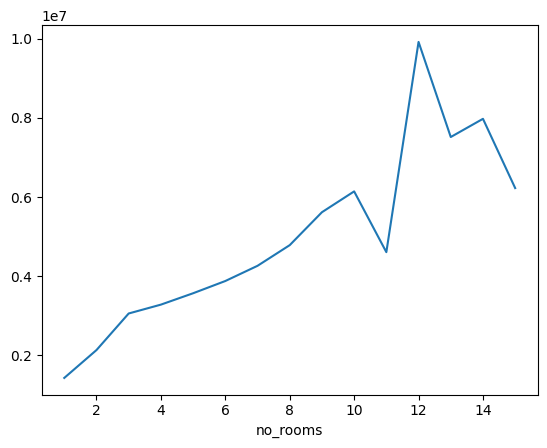

In [24]:
df.groupby('no_rooms')['purchase_price'].mean().plot();

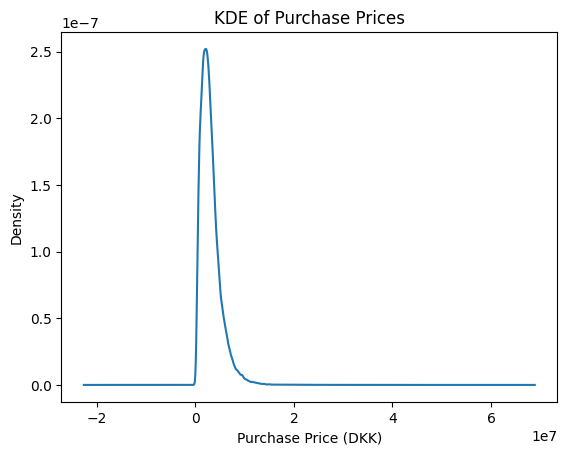

In [25]:
# KDE plot for purchase_price in 2024
df['purchase_price'].plot(kind='kde')
plt.title('KDE of Purchase Prices')
plt.xlabel('Purchase Price (DKK)')
plt.ylabel('Density')
plt.show()

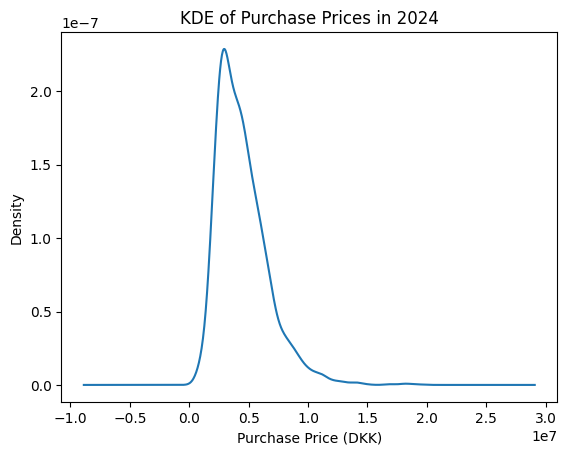

In [12]:
# KDE plot for purchase_price in 2024
df[df['date'] >= '2024-01-01']['purchase_price'].plot(kind='kde')
plt.title('KDE of Purchase Prices in 2024')
plt.xlabel('Purchase Price (DKK)')
plt.ylabel('Density')
plt.show()

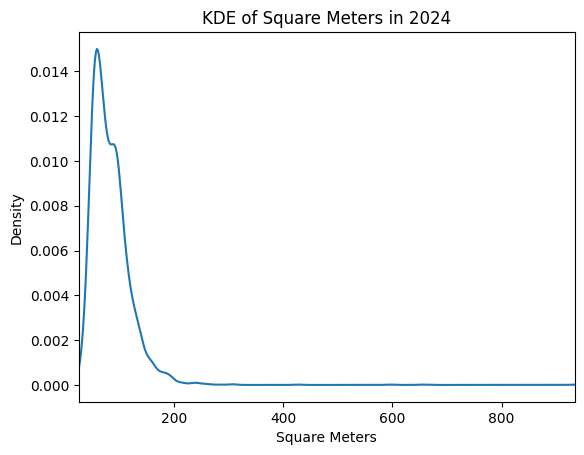

In [13]:
sqm_2024 = df[df['date'] >= '2024-01-01']['sqm']
lower, upper = sqm_2024.quantile([0, 1])
sqm_2024.plot(kind='kde')
plt.title('KDE of Square Meters in 2024')
plt.xlabel('Square Meters')
plt.ylabel('Density')
plt.xlim(lower, upper)
plt.show()

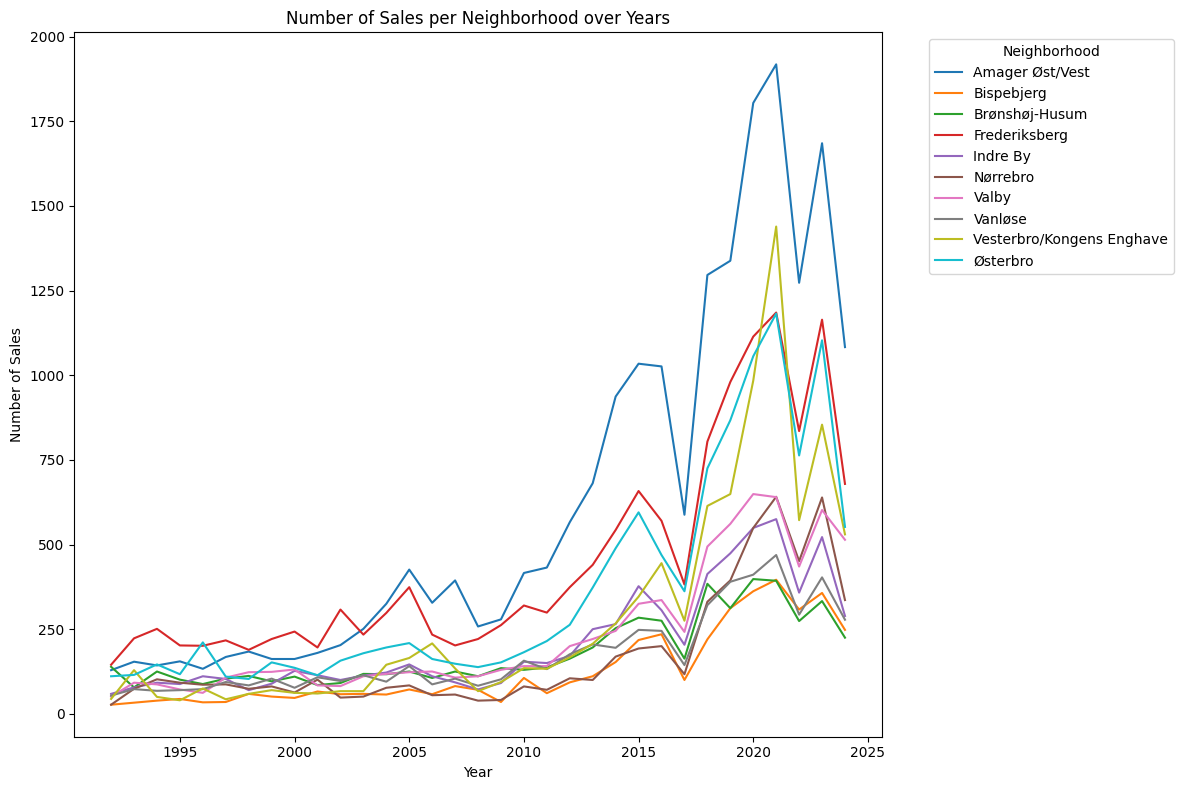

In [5]:
# Plot number of sales per neighborhood over the years
import matplotlib.pyplot as plt

# Group by year and neighborhood, count the number of sales
sales_per_year_neigh = df.groupby([df['date'].dt.year, 'neighborhood']).size().unstack()

# Plot as line chart
sales_per_year_neigh.plot(kind='line', figsize=(12, 8))
plt.title('Number of Sales per Neighborhood over Years')
plt.xlabel('Year')
plt.ylabel('Number of Sales')
plt.legend(title='Neighborhood', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()